/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6534/2659244667.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


cluster
0    1114
1    1211
2    2061
3    1009
4     181
Name: count, dtype: int64
Cluster 0: ['submission', 'choke', 'naked', 'rear', 'ufc', 'def', 'vs', 'guillotine', 'fight', 'night']
Cluster 1: ['28', '29', 'decision', '00', 'unanimous', 'split', 'vs', '27', 'ufc', 'def']
Cluster 2: ['punches', 'tko', 'ufc', 'def', 'ko', 'vs', 'heavyweight', 'fight', 'night', 'welterweight']
Cluster 3: ['30', '27', 'unanimous', 'decision', '00', '26', 'vs', 'ufc', 'def', '29']
Cluster 4: ['team', 'finale', 'fighter', 'ultimate', '12', '28', 'vs', '29', '30', '06']


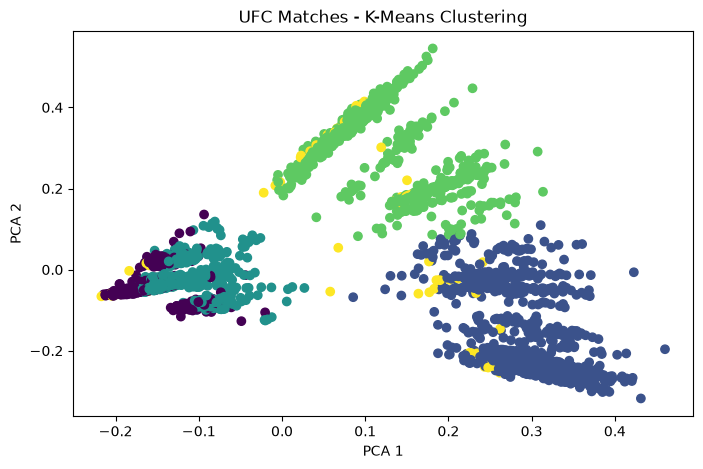

Done!


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("ufc_matches_to_date_may09.csv")

# 3. Select text columns and combine them
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 4. NLP: Convert text into TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(df["text"])

# 5. K-Means clustering
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show cluster sizes
print(df["cluster"].value_counts().sort_index())

# 7. Show important words in each cluster
words = tfidf.get_feature_names_out()

for i in range(k):
    top_words = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"Cluster {i}:", [words[j] for j in top_words])

# 8. PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("UFC Matches - K-Means Clustering")
plt.show()

# 9. Save results
df.to_csv("ufc_kmeans_results.csv", index=False)

print("Done!")